In [1]:
from pathlib import Path
from ocularrigidity.consts import ROOT_DATA_SMB
import numpy as np


# IMPORTANT: compression reading and loading use FFMPEG for efficiency! You do need it, and the default
# values currently hardcode my own path to ffmpeg.
from ocularrigidity.data.compression import mp4_to_cube, read_gray


from ocularrigidity.data.io import load_cube

# This is my own video
path_data = Path(
    "F:/NASA_Spectralis_Pulse/videoFolder/1"
)  # Path to the folder containing the cube.bin.

# Note: you can either use a localpath or link to a path mounted with SMB.
# In the latter case, make sure you did mount the SMB share.

# data = load_cube(path_data)

path_to_ffmpeg = "C:/ProgramData/chocolatey/lib/ffmpeg/tools/ffmpeg/bin/ffmpeg.exe"  # Path to ffmpeg, which you need to have installed on your system. Y
# If you have a video (mp4):
data = read_gray(
   path_data / "compressedOCT_woOutliers_median_threshold.mj2"
     )  # This time, you need to provide the full path to the video, not just the folder.
# If you have a video (.mkv):
#data = read_gray(path_data / "video.mkv", ffmpeg=path_to_ffmpeg)

W0616 11:50:00.443000 374168 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
c:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from ocularrigidity.data.io import save_mask
from ocularrigidity.segmentation.utils import get_choroid_segmentation_model
from ocularrigidity.segmentation.inference import infer

model = (
    get_choroid_segmentation_model()
)  # Model is automatically downloaded on first call.

scale_factors_ls = [2.25, 2.5, 2.75, 3]
for sc in scale_factors_ls :
    # See the docstring of the infer function for more details on the parameters. The most important ones are scale_factor, which controls the resizing of the input, which controls the pixel size, and batch_size, which controls the speed of inference (the larger, the faster, but also the more VRAM you need).
    # The model was trained with a pixel size, axial of 1.95um and lateral of 5.95um (at a resolution of 1536x1024). Match to your data.
    mask = infer(model, data, scale_factor=(sc), batch_size=16, device="cuda:0")
    # Save the masks as a numpy array for later use:
    OUTPUT_MASK_PATH = Path(f"F:/NASA_Spectralis_Pulse/maskFolder/1/mask_{sc}.npz")
    save_mask(mask, OUTPUT_MASK_PATH)  # Use packed + zstd compressed, so very light

c:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


C:\Users\transformer\AppData\Local\Temp\ipykernel_374168\1888774168.py:15: UserWarning: linewidths is ignored by contourf
  plt.contourf(mask[idx_m],cmap="Reds",linestyles="solid",alpha=[0,0.2],linewidths=1)


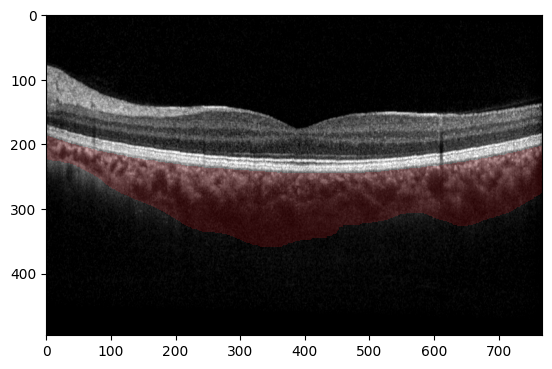

C:\Users\transformer\AppData\Local\Temp\ipykernel_374168\1888774168.py:20: UserWarning: linewidths is ignored by contourf
  plt.contourf(mask[idx_m+2],cmap="Reds",linestyles="solid",alpha=[0,0.2],linewidths=1)


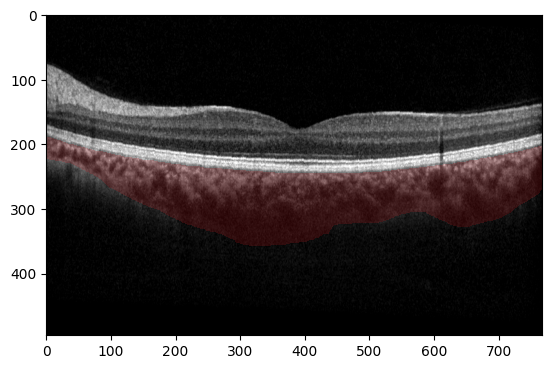

2


In [4]:
from pathlib import Path
from ocularrigidity.data.io import load_mask
import matplotlib.pyplot as plt
scale_factors_ls = [0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3]
sc = scale_factors_ls[7]
idx_m = 90
path_mask = Path(f"f:/NASA_Spectralis_Pulse/maskFolder/1/mask_{sc}.npz")
path_video = Path("F:/NASA_Spectralis_Pulse/videoFolder/1/compressedOCT_woOutliers_median_threshold.mj2")

video = read_gray(path_video)
mask = load_mask(path_mask)

plt.imshow(video[idx_m],cmap="gray")
# plt.imshow(mask[idx_m],alpha=mask[idx_m]*0.2,cmap="Reds")
plt.contourf(mask[idx_m],cmap="Reds",linestyles="solid",alpha=[0,0.2],linewidths=1)
plt.show()

plt.imshow(video[idx_m+2],cmap="gray")
# plt.imshow(mask[idx_m],alpha=mask[idx_m]*0.2,cmap="Reds")
plt.contourf(mask[idx_m+2],cmap="Reds",linestyles="solid",alpha=[0,0.2],linewidths=1)
plt.show()

print(sc)